4))


DATA-110 MID TERM EXAM

NAME : JEEVAN C

ID : 0626576

In [54]:
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'GLB.Ts+dSST.csv', 'owid-co2-data.csv']


In [55]:
import pandas as pd

co2 = pd.read_csv("owid-co2-data.csv")

# Keep only World data
co2_world = co2[co2["country"] == "World"]

# Keep only required columns
co2_world = co2_world[["year", "co2"]]

# Rename columns
co2_world.columns = ["Year", "CO2_Emissions"]

print(co2_world.head())

       Year  CO2_Emissions
49511  1750          9.306
49512  1751          9.407
49513  1752          9.505
49514  1753          9.610
49515  1754          9.734


In [56]:
temp = pd.read_csv("GLB.Ts+dSST.csv", skiprows=1)

# Keep Year and annual mean column
temp = temp[["Year", "J-D"]]

# Rename columns
temp.columns = ["Year", "Temp_Anomaly"]

print(temp.head())

   Year Temp_Anomaly
0  1880         -.18
1  1881         -.10
2  1882         -.12
3  1883         -.18
4  1884         -.29


In [57]:
merged = pd.merge(co2_world, temp, on="Year", how="inner")

print(merged.head())
print("Total Years:", len(merged))

   Year  CO2_Emissions Temp_Anomaly
0  1880        858.228         -.18
1  1881        888.173         -.10
2  1882        938.158         -.12
3  1883        997.862         -.18
4  1884       1009.762         -.29
Total Years: 145


In [58]:
print(merged.describe())

              Year  CO2_Emissions
count   145.000000     145.000000
mean   1952.000000   12629.489331
std      42.001984   11765.032450
min    1880.000000     858.228000
25%    1916.000000    3197.750000
50%    1952.000000    6467.700000
75%    1988.000000   21918.756000
max    2024.000000   38598.578000


In [59]:
print(merged.isnull().sum())

Year             0
CO2_Emissions    0
Temp_Anomaly     0
dtype: int64


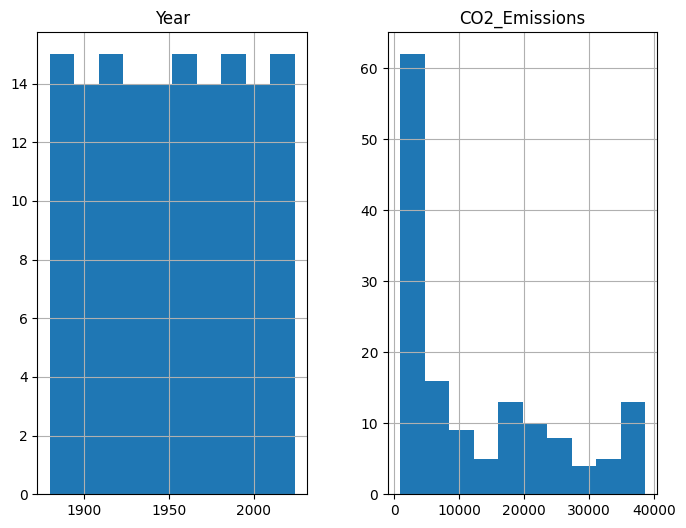

In [60]:
import matplotlib.pyplot as plt

merged.hist(figsize=(8,6))
plt.show()

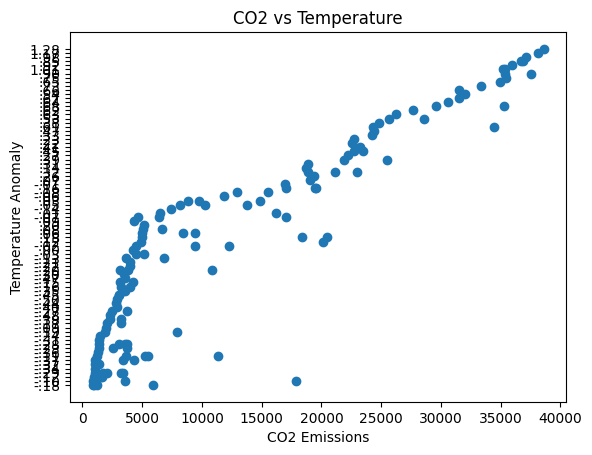

In [61]:
plt.scatter(merged["CO2_Emissions"], merged["Temp_Anomaly"])
plt.xlabel("CO2 Emissions")
plt.ylabel("Temperature Anomaly")
plt.title("CO2 vs Temperature")
plt.show()

In [62]:
correlation = merged.corr()
print(correlation)

                   Year  CO2_Emissions  Temp_Anomaly
Year           1.000000       0.936426      0.876173
CO2_Emissions  0.936426       1.000000      0.935052
Temp_Anomaly   0.876173       0.935052      1.000000


In [63]:
X = merged[["CO2_Emissions"]]
y = merged["Temp_Anomaly"]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R2:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression R2: 0.8948830418645788
Linear Regression RMSE: 0.13200366252819995


In [66]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree R2:", r2_dt)
print("Decision Tree RMSE:", rmse_dt)

Decision Tree R2: 0.8733372833016763
Decision Tree RMSE: 0.14490186929138604


In [67]:
print("Linear Regression - R2:", r2_lr)
print("Decision Tree - R2:", r2_dt)

Linear Regression - R2: 0.8948830418645788
Decision Tree - R2: 0.8733372833016763


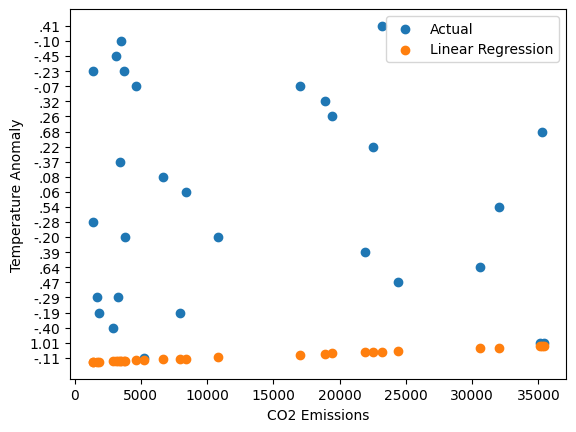

In [68]:
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred_lr, label="Linear Regression")
plt.legend()
plt.xlabel("CO2 Emissions")
plt.ylabel("Temperature Anomaly")
plt.show()

In [69]:
new_value = [[40000]]
prediction = lr.predict(new_value)

print("Predicted Temperature:", prediction)

Predicted Temperature: [0.92508701]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
